# Exploratory Data Analysis (EDA)

## 1. Imports and configuration

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_theme(style="whitegrid")

train_df = pd.read_csv("datasets/train_hotel_reviews.csv")
test_df = pd.read_csv("datasets/test_hotel_reviews.csv")

print(train_df.shape)
print(test_df.shape)

(64097, 9)
(16025, 9)


## 2. Sentiment Distribution

In [3]:
print(train_df["sentiment"].value_counts())

#count the number of positive and negative reviews in the training dataset
print(
    train_df["sentiment"]
    .value_counts(normalize=True)
    .round(3)
)

sentiment
1    45758
0    18339
Name: count, dtype: int64
sentiment
1    0.714
0    0.286
Name: proportion, dtype: float64


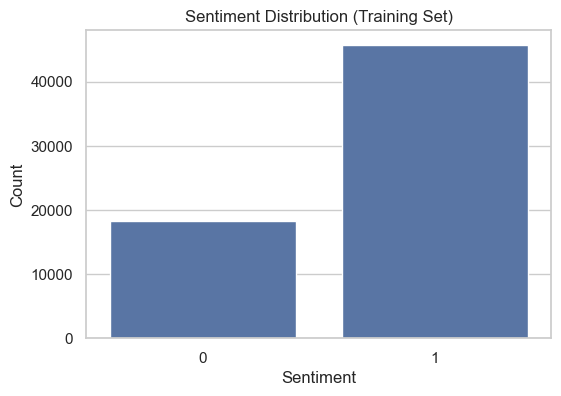

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x="sentiment"
)

plt.title("Sentiment Distribution (Training Set)")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## 3. Review Length Analysis

In [5]:
#count the size of the reviews in the training dataset
train_df["review_length"] = (
    train_df["review_text"]
    .astype(str)
    .str.len()
)

train_df["review_length"].describe()


count    64097.000000
mean      1014.507730
std        791.212076
min         31.000000
25%        503.000000
50%        803.000000
75%       1276.000000
max      13389.000000
Name: review_length, dtype: float64

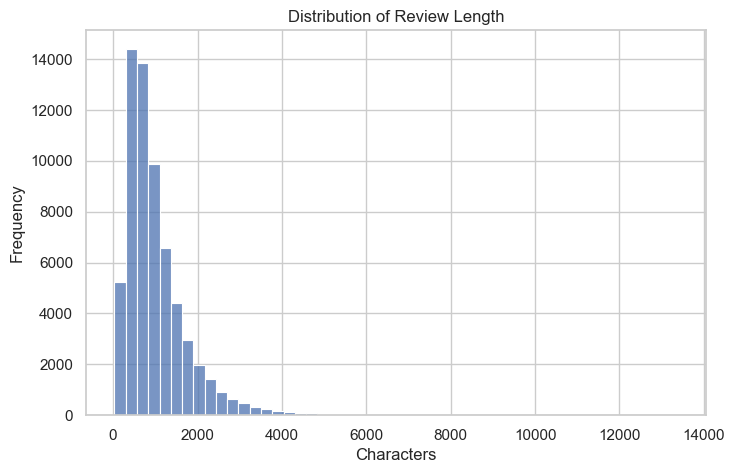

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["review_length"],
    bins=50
)

plt.title("Distribution of Review Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

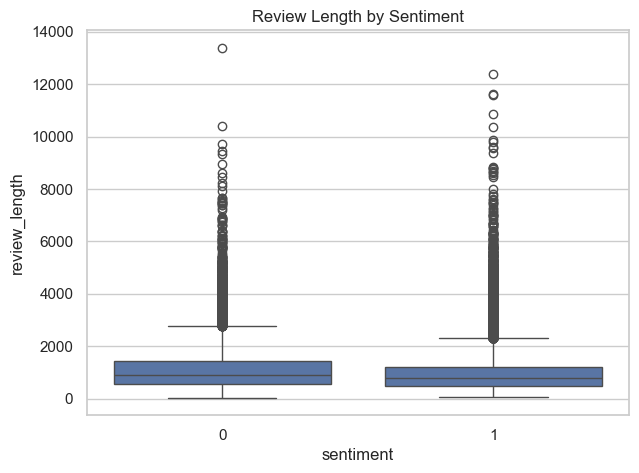

In [7]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train_df,
    x="sentiment",
    y="review_length"
)

plt.title("Review Length by Sentiment")

plt.show()

## 4. Word Count Analysis

In [8]:
#word count analysis
train_df["word_count"] = (
    train_df["review_text"]
    .astype(str)
    .str.split()
    .apply(len)
)

train_df["word_count"].describe()

count    64097.000000
mean       184.099911
std        146.592802
min          2.000000
25%         90.000000
50%        145.000000
75%        233.000000
max       2307.000000
Name: word_count, dtype: float64

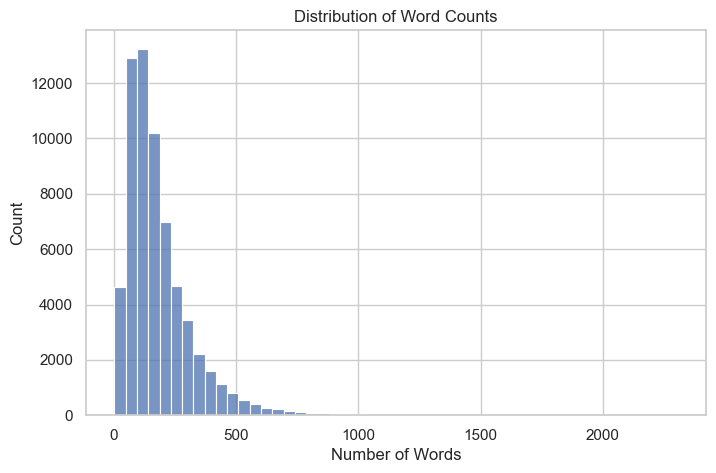

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["word_count"],
    bins=50
)

plt.title("Distribution of Word Counts")
plt.xlabel("Number of Words")

plt.show()

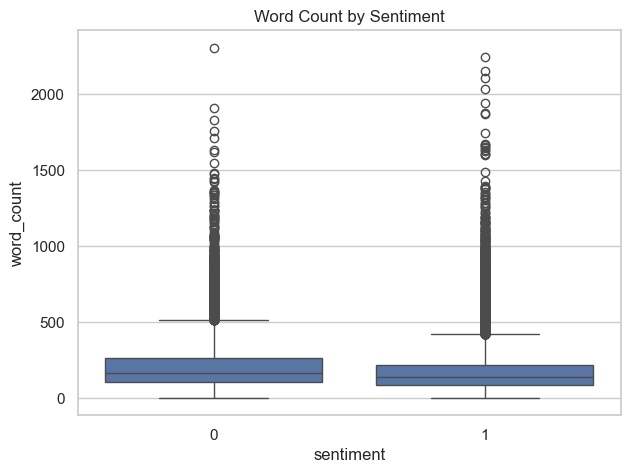

In [10]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train_df,
    x="sentiment",
    y="word_count"
)

plt.title("Word Count by Sentiment")

plt.show()

## 5. Hotel Rating Relationships

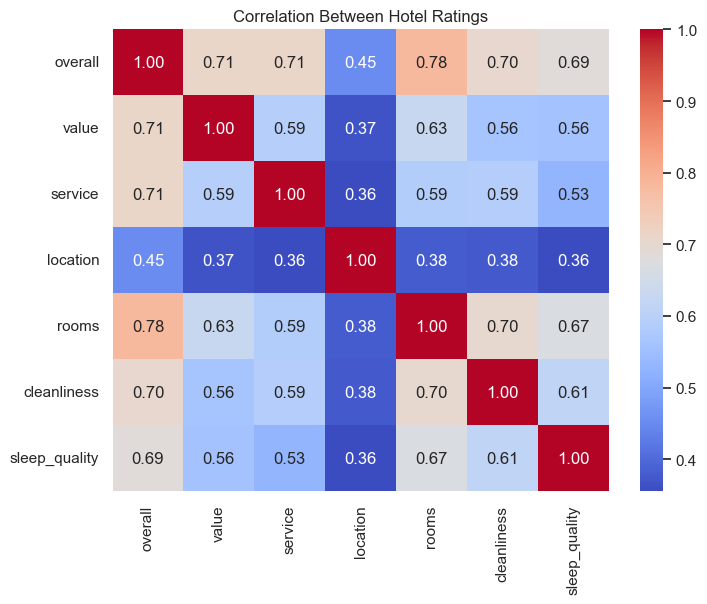

In [11]:
#correlation heatmap of ratings 
rating_cols = [
    "overall",
    "value",
    "service",
    "location",
    "rooms",
    "cleanliness",
    "sleep_quality"
]

corr = train_df[rating_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Hotel Ratings")

plt.show()

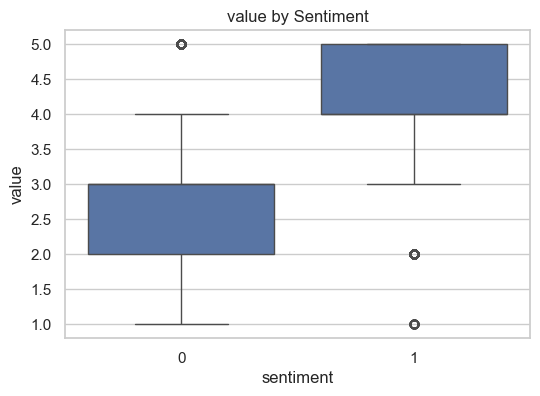

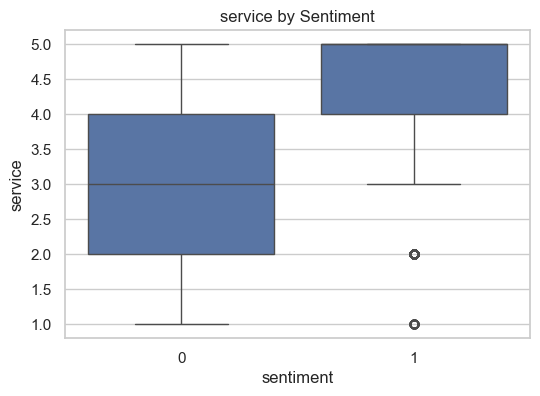

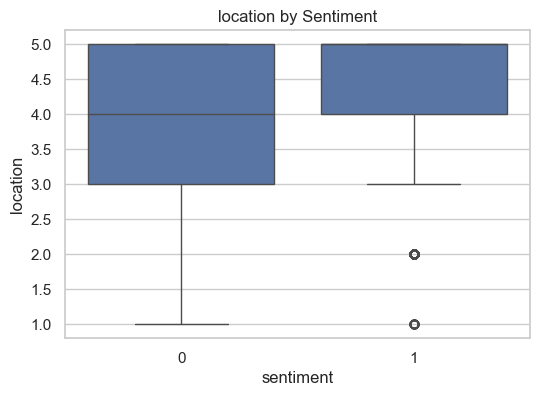

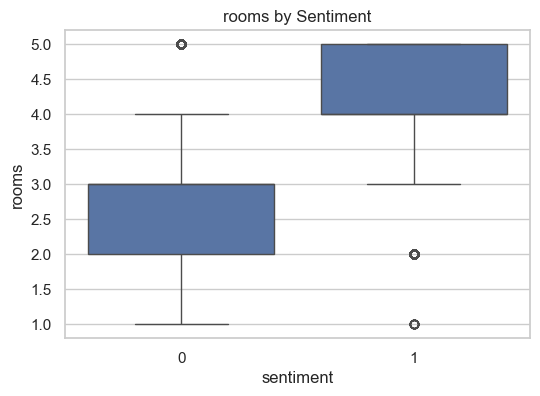

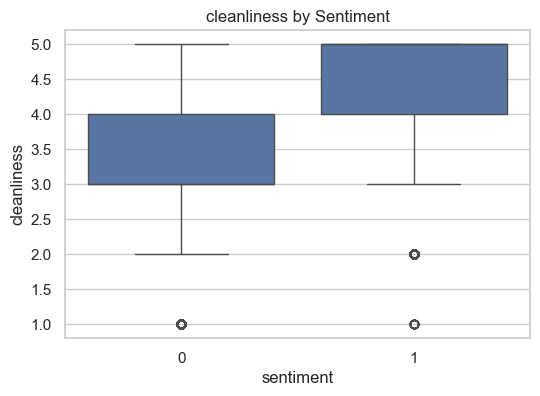

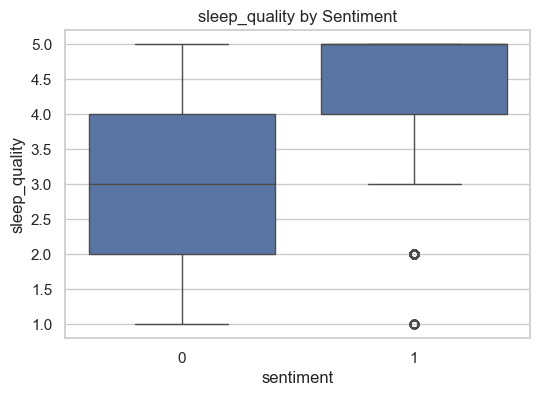

In [12]:
rating_features = [
    "value",
    "service",
    "location",
    "rooms",
    "cleanliness",
    "sleep_quality"
]

for col in rating_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=train_df,
        x="sentiment",
        y=col
    )

    plt.title(f"{col} by Sentiment")

    plt.show()

## 6. Text Exploration

In [13]:
#Most common words in positive and negative reviews
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

X = vectorizer.fit_transform(
    train_df["review_text"]
)

In [14]:
word_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "frequency": X.sum(axis=0).A1
})

word_freq = word_freq.sort_values(
    "frequency",
    ascending=False
)

word_freq.head(20)

,word,frequency
13,hotel,149196
22,room,120270
12,great,58883
27,stay,50617
18,nice,47473
11,good,47293
17,location,43340
23,rooms,41198
26,staff,38492
24,service,32070


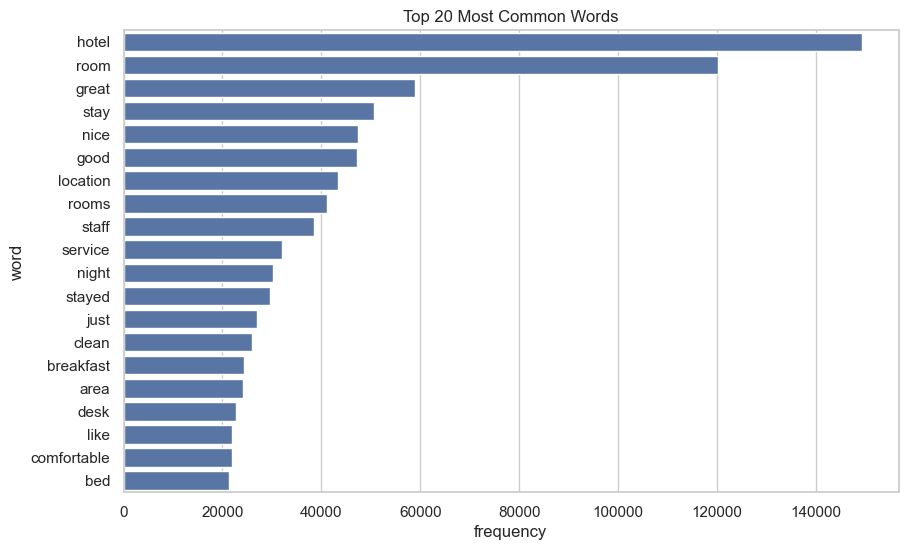

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=word_freq.head(20),
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Common Words")

plt.show()

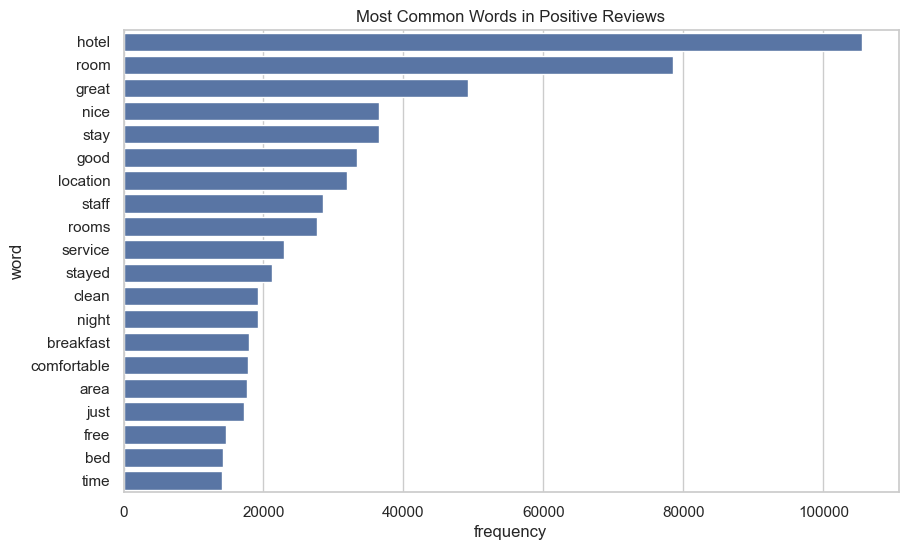

In [16]:
#most common words in positive reviews
positive_reviews = train_df[
    train_df["sentiment"] == 1
]["review_text"]

positive_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X_pos = positive_vectorizer.fit_transform(
    positive_reviews
)

positive_words = pd.DataFrame({
    "word": positive_vectorizer.get_feature_names_out(),
    "frequency": X_pos.sum(axis=0).A1
})

positive_words = positive_words.sort_values(
    "frequency",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=positive_words,
    x="frequency",
    y="word"
)

plt.title("Most Common Words in Positive Reviews")

plt.show()

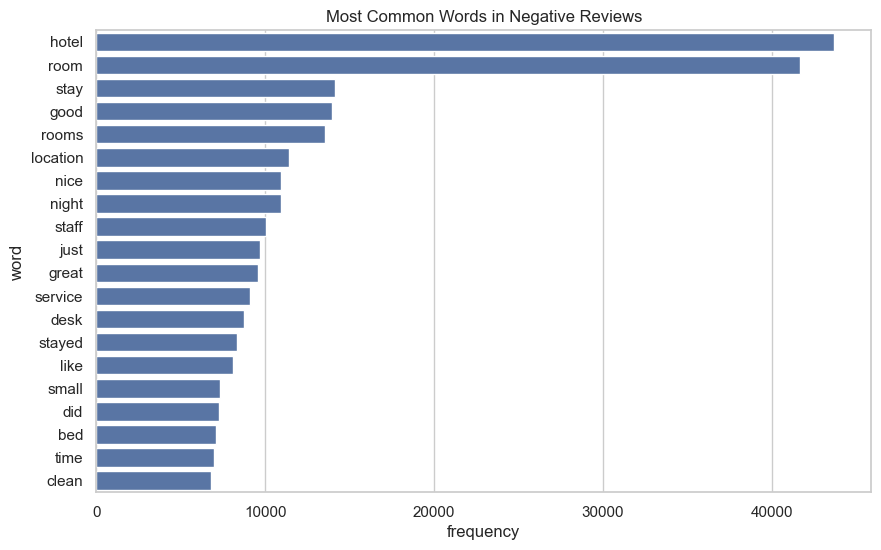

In [17]:
#most common words in negative reviews
negative_reviews = train_df[
    train_df["sentiment"] == 0
]["review_text"]

negative_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X_neg = negative_vectorizer.fit_transform(
    negative_reviews
)

negative_words = pd.DataFrame({
    "word": negative_vectorizer.get_feature_names_out(),
    "frequency": X_neg.sum(axis=0).A1
})

negative_words = negative_words.sort_values(
    "frequency",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=negative_words,
    x="frequency",
    y="word"
)

plt.title("Most Common Words in Negative Reviews")

plt.show()

In [18]:
#bigram analysis
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(
    train_df["review_text"]
)

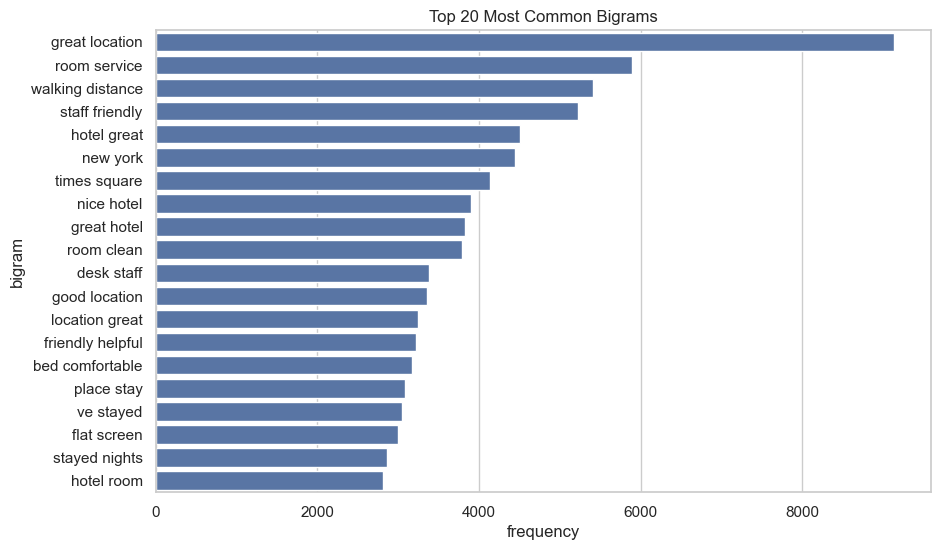

In [19]:
bigram_freq = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "frequency": X_bigram.sum(axis=0).A1
})

bigram_freq = bigram_freq.sort_values(
    "frequency",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_freq,
    x="frequency",
    y="bigram"
)

plt.title("Top 20 Most Common Bigrams")

plt.show()

In [20]:
for col in rating_features:

    train_df[col + "_missing"] = (
        train_df[col]
        .isnull()
        .astype(int)
    )

for col in rating_features:

    print("\n", col)

    print(
        pd.crosstab(
            train_df["sentiment"],
            train_df[col + "_missing"],
            normalize="index"
        )
    )


 value
value_missing         0         1
sentiment                        
0              0.896341  0.103659
1              0.914835  0.085165

 service
service_missing         0         1
sentiment                          
0                0.887780  0.112220
1                0.912649  0.087351

 location
location_missing         0         1
sentiment                           
0                 0.793936  0.206064
1                 0.810612  0.189388

 rooms
rooms_missing         0         1
sentiment                        
0              0.835978  0.164022
1              0.849054  0.150946

 cleanliness
cleanliness_missing         0         1
sentiment                              
0                    0.898141  0.101859
1                    0.916736  0.083264

 sleep_quality
sleep_quality_missing         0         1
sentiment                                
0                      0.543214  0.456786
1                      0.579986  0.420014


In [21]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X_tfidf = tfidf.fit_transform(
    train_df["review_text"]
)

scores = np.asarray(
    X_tfidf.mean(axis=0)
).ravel()

tfidf_df = pd.DataFrame({
    "word": tfidf.get_feature_names_out(),
    "score": scores
})

tfidf_df = tfidf_df.sort_values(
    "score",
    ascending=False
)

tfidf_df.head(20)

,word,score
423,hotel,0.086848
739,room,0.073297
382,great,0.054380
582,nice,0.045133
378,good,0.044447
831,stay,0.043170
502,location,0.041840
740,rooms,0.038927
819,staff,0.036944
763,service,0.032844
